# Imports

In [59]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

# EDA

In [2]:
df = pd.read_csv("telecom_churn.csv")

In [27]:
df.shape

(3333, 11)

In [55]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

In [68]:
df.columns = ['Churn', 'time_last_transaction', 'time_last_login', 'price', 'quantity',
       'store_type', 'tva_precentage', 'tva_type', 'has_wallet', 'balance',
       'operating_hours']

In [69]:
df.columns

Index(['Churn', 'time_last_transaction', 'time_last_login', 'price',
       'quantity', 'store_type', 'tva_precentage', 'tva_type', 'has_wallet',
       'balance', 'operating_hours'],
      dtype='object')

In [57]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

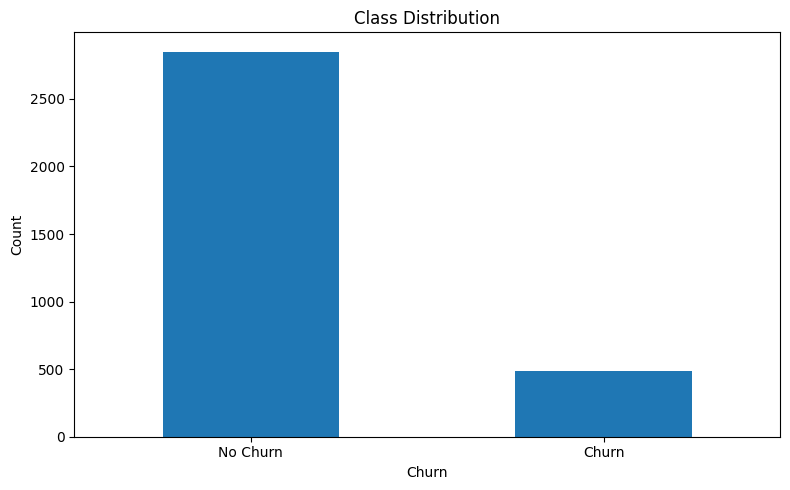

# Helper functions

In [187]:
def return_report(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    return [accuracy, precision, recall, f1, roc_auc]

In [171]:
def plot_cofusion_matrix(y_test, y_pred, path, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    title = model_name + " Confusion Matrix"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()

In [172]:
def plot_roc_curve(y_test, y_prob, path, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
    title = model_name + " ROC Curve"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()

In [173]:
def plot_precision_recall_curve(y_test,y_prob, path, model_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
    title = model_name + " Precision-Recall Curve"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()

In [174]:
def plot_prob_distribution(y_test, y_prob, path, model_name):
    plt.figure(figsize=(8, 5))
    plt.hist(y_prob[y_test == 0], bins=20, alpha=0.7, label="Predicted No Churn")
    plt.hist(y_prob[y_test == 1], bins=20, alpha=0.7, label="Predicted Churn")
    plt.xlabel(model_name + " Predicted Churn Probability")
    plt.ylabel("Count")
    title = model_name + " Predicted Probability Distribution"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()

In [175]:
def plot_score_distribution(loyalty_score, path, model_name):
    plt.figure(figsize=(8, 5))
    plt.hist(loyalty_score, bins=20, alpha=0.8)
    plt.xlabel(model_name + " Loyalty Score")
    plt.ylabel("Count")
    title = model_name + " Loyalty Score Distribution"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()

In [208]:
def plot_learning_curve(model, X, y, path, model_name = ''):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=None
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    title = model_name + ' learning curve'
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label= model_name + " Training Score")
    plt.plot(train_sizes, val_mean, marker="o", label=model_name + " Validation Score")
    plt.xlabel(model_name + " Training Set Size")
    plt.ylabel(model_name + " F1 Score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(path + title)
    # plt.show()


In [209]:
def plot_evaluation(model, X_test, y_test, path, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, y_pred))
    plot_cofusion_matrix(y_test, y_pred, path, model_name)
    plot_prob_distribution(y_test, y_prob, path, model_name)
    plot_precision_recall_curve(y_test, y_prob, path, model_name)
    plot_roc_curve(y_test, y_prob, path, model_name)
    plot_learning_curve(model, X, y, path, model_name)

In [26]:
def cashback(churn_prob, c_min=1, c_max=10):
    loyalty = 1 - churn_prob
    return c_min + (c_max - c_min) * loyalty

In [49]:
def cashback(loyalty, spending, c_min=1, c_max=10, alpha=0.7):
    score = alpha * loyalty + (1 - alpha) * spending
    return c_min + (c_max - c_min) * (score ** 2)

# EDA

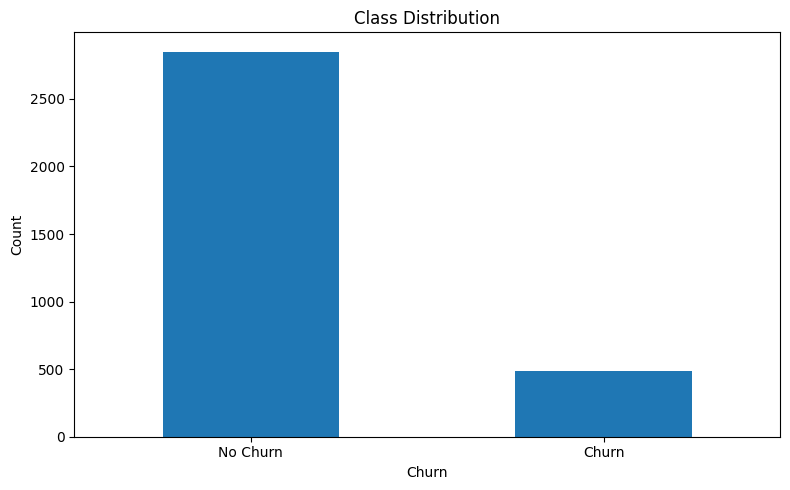

In [114]:
plt.figure(figsize=(8, 5))
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No Churn", "Churn"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('./eda/chur distribution')
plt.show()

In [85]:
df.head()

,Churn,time_last_transaction,tva_type,has_wallet,quantity,store_type,price,time_last_login,balance,operating_hours,tva_precentage
0,0,128,1,1,4.0,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,5.0,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,1.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,1.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,1.0,3,166.7,113,41.0,7.42,10.1


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Churn                  3333 non-null   int64  
 1   time_last_transaction  3333 non-null   int64  
 2   tva_type               3333 non-null   int64  
 3   has_wallet             3333 non-null   int64  
 4   quantity               3333 non-null   float64
 5   store_type             3333 non-null   int64  
 6   price                  3333 non-null   float64
 7   time_last_login        3333 non-null   int64  
 8   balance                3333 non-null   float64
 9   operating_hours        3333 non-null   float64
 10  tva_precentage         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [89]:
df.describe()

,Churn,time_last_transaction,tva_type,has_wallet,quantity,store_type,price,time_last_login,balance,operating_hours,tva_precentage
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,1.767177,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.309460,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,1.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,1.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,3.000000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,6.000000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [95]:
def plot_hist(data, xlabel, title):
    plt.hist(data, bins=25)
    plt.xlabel(xlabel)
    plt.ylabel('value')
    plt.title(title)
    plt.savefig('./eda/' + title +'.png')
    plt.tight_layout

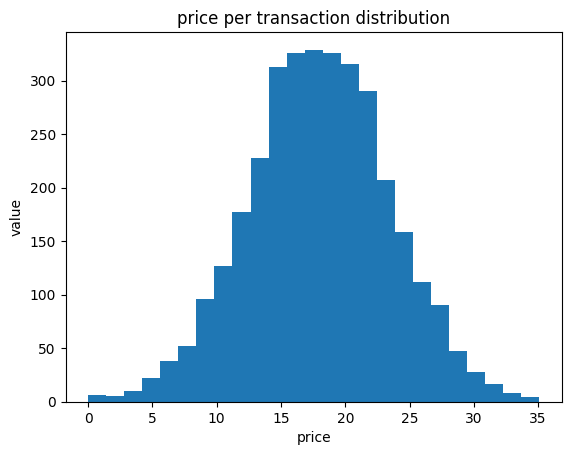

In [104]:
df['price'] = df['price'] / 10
plot_hist(df['price'], 'price', 'price per transaction distribution')

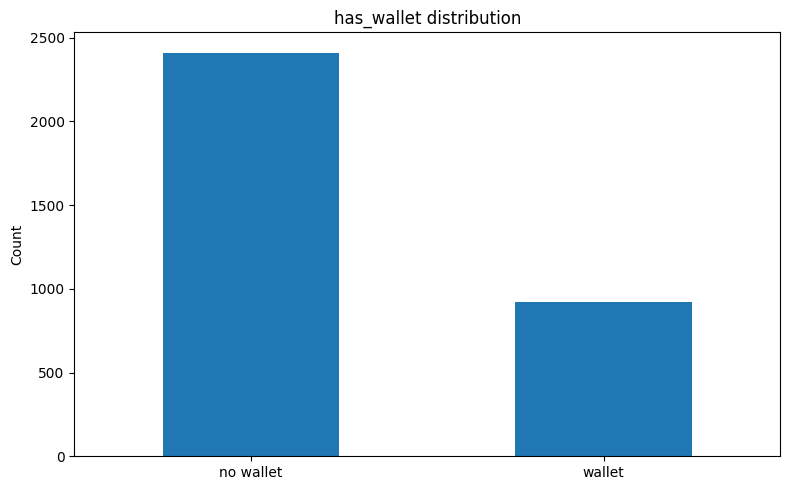

In [102]:
plt.figure(figsize=(8, 5))
df['has_wallet'].value_counts().sort_index().plot(kind="bar", xlabel='')
plt.xticks([0, 1], ["no wallet", "wallet"], rotation=0)
plt.title("has_wallet distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig('./eda/has_wallet.png')
plt.show()

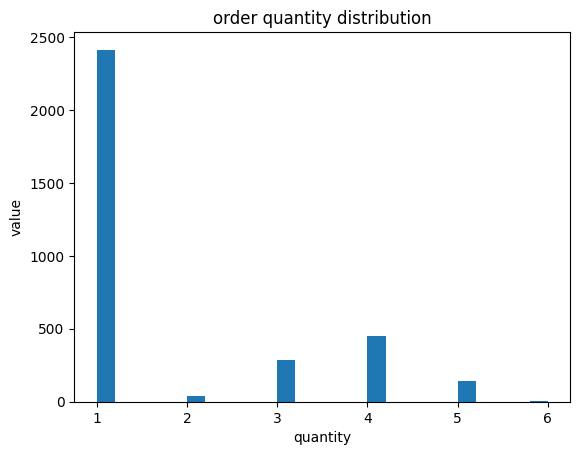

In [103]:
plot_hist(df['quantity'], 'quantity', 'order quantity distribution')

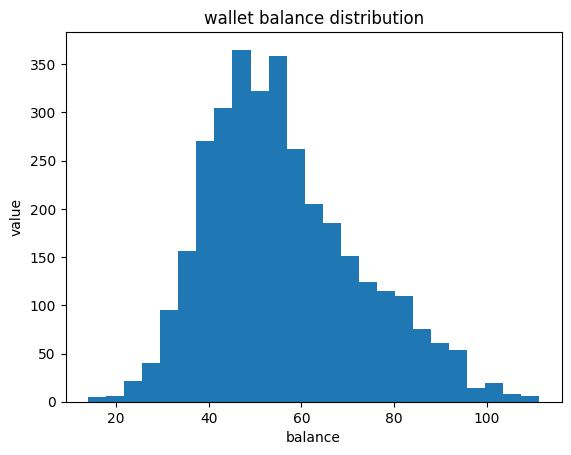

In [105]:
plot_hist(df['balance'], 'balance', 'wallet balance distribution')

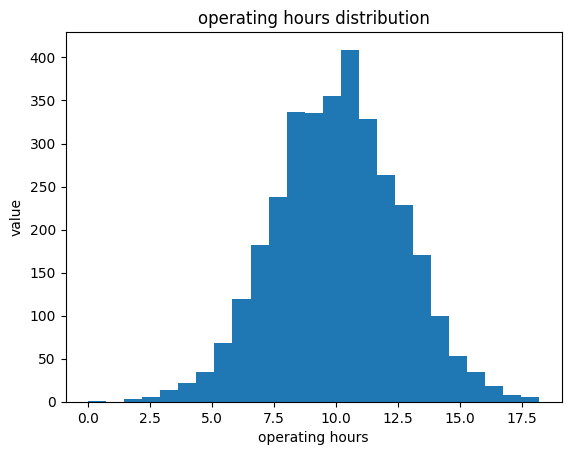

In [106]:
plot_hist(df['operating_hours'], 'operating hours', 'operating hours distribution')

In [ ]:
def plot_scatter(x, y, xlabel, ylabel):
    plt.scatter(x, y)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    title = xlabel + 'vs' + ylabel
    plt.title(title)
    plt.savefig('./eda/' + title)

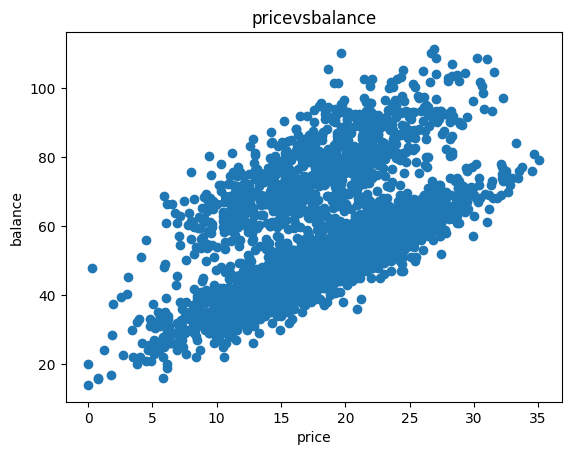

In [113]:
plot_scatter(df['price'], df['balance'], xlabel='price', ylabel='balance')

# Training

## preprocessing

In [116]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logistic regression

In [139]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ],
    remainder="drop"
)

logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, max_iter=5000))
])

logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__penalty": ["l2"]
}

logreg_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features)
    ],
    remainder="drop"
)

In [140]:
logreg_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['AccountWeeks',
                                                                          'ContractRenewal',
                                                                          'DataPlan',
                                                                          'DataUsage',
                                                                          'CustServCalls',
                                                                          'DayMins',
                                                                          'DayCalls',
                                                                          'MonthlyCharge',
                                                                          'OverageFee',
                                                                          'RoamMins'])])),
                                       ('classifier',
                                        LogisticRegression(max_iter=5000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['liblinear', 'lbfgs']},
             scoring='roc_auc', verbose=1)

random forest 

In [129]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [130]:
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['AccountWeeks',
                                                                                'ContractRenewal',
                                                                                'DataPlan',
                                                                                'DataUsage',
                                                                                'CustServCalls',
                                                                                'DayMins',
                                                                                'DayCalls',
                                                                                'MonthlyCharge',
                                                                                'OverageFee',
                                                                                'RoamMins'])])),
                                             ('classifier',
                                              RandomForestClassifier(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'classifier__max_depth': [None, 5, 10,
                                                                  15, 20],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300,
                                                                     500]},
                   random_state=42, scoring='roc_auc', verbose=1)

xgboost

In [131]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_param_dist = {
    "classifier__n_estimators": [100, 200, 300, 500],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__gamma": [0, 0.1, 0.3, 0.5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [132]:
xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['AccountWeeks',
                                                                                'ContractRenewal',
                                                                                'DataPlan',
                                                                                'DataUsage',
                                                                                'CustServCalls',
                                                                                'DayMins',
                                                                                'DayCalls',
                                                                                'MonthlyCharge',
                                                                                'OverageFee',
                                                                                'RoamMins'])])),
                                             ('classifier',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            c...
                   param_distributions={'classifier__colsample_bytree': [0.7,
                                                                         0.8,
                                                                         0.9,
                                                                         1.0],
                                        'classifier__gamma': [0, 0.1, 0.3, 0.5],
                                        'classifier__learning_rate': [0.01,
                                                                      0.05, 0.1,
                                                                      0.2],
                                        'classifier__max_depth': [3, 4, 5, 6,
                                                                  8],
                                        'classifier__min_child_weight': [1, 3,
                                                                         5],
                                        'classifier__n_estimators': [100, 200,
                                                                     300, 500],
                                        'classifier__subsample': [0.7, 0.8, 0.9,
                                                                  1.0]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
plot_evaluation(logreg_search, X_test, y_test, './models/logistic_regression/', 'Logistic Regression')

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.85      0.64      0.73        97

    accuracy                           0.93       667
   macro avg       0.90      0.81      0.84       667
weighted avg       0.93      0.93      0.93       667

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 

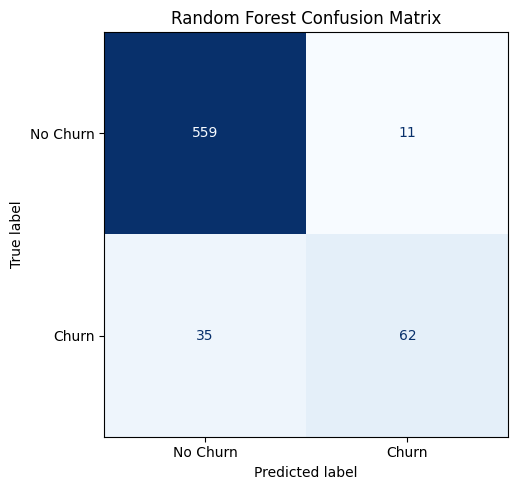

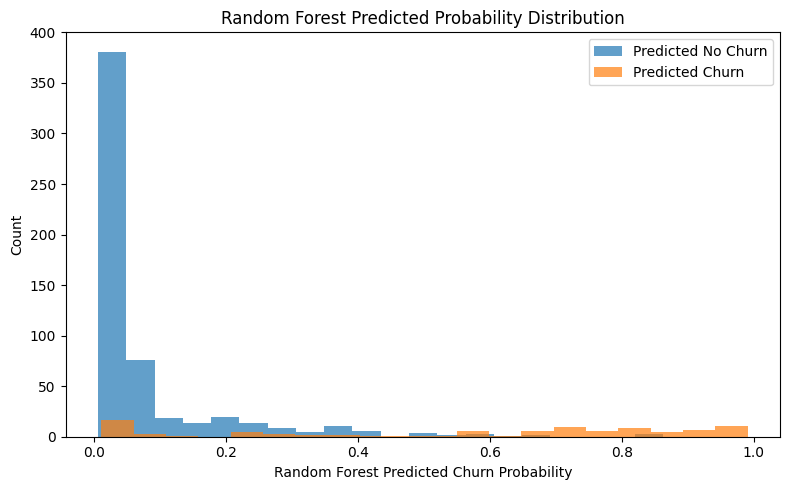

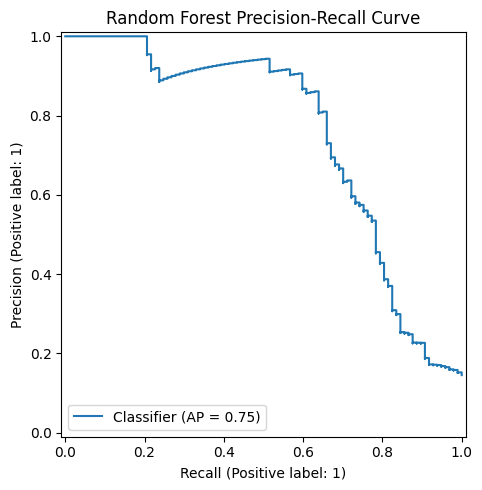

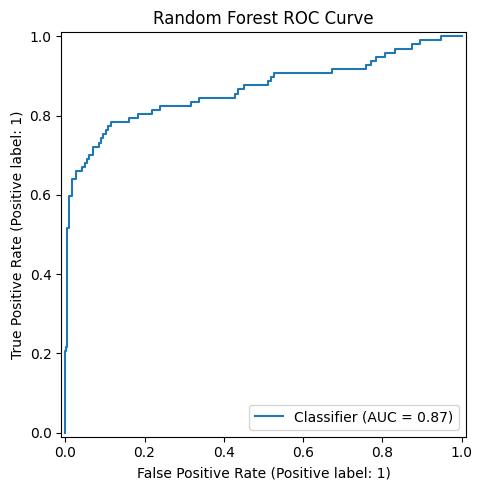

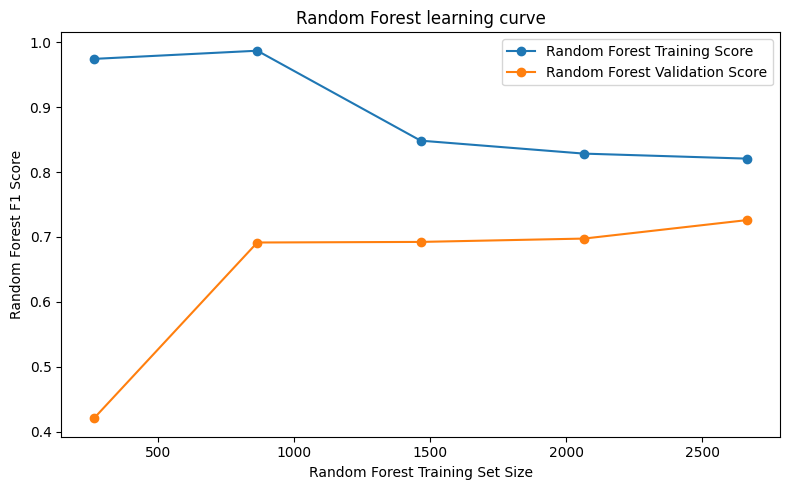

In [211]:
plot_evaluation(rf_search, X_test, y_test, './models/random_forest/', 'Random Forest')

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       570
           1       0.82      0.58      0.68        97

    accuracy                           0.92       667
   macro avg       0.88      0.78      0.82       667
weighted avg       0.92      0.92      0.91       667

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 

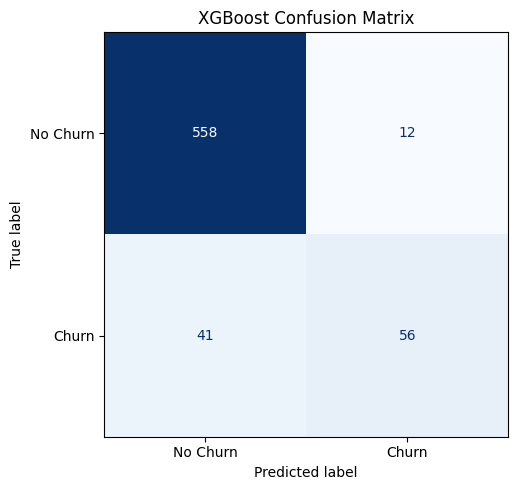

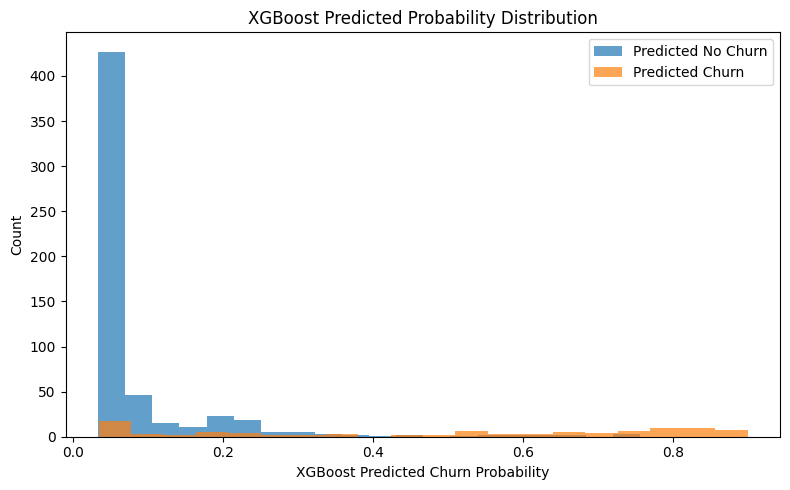

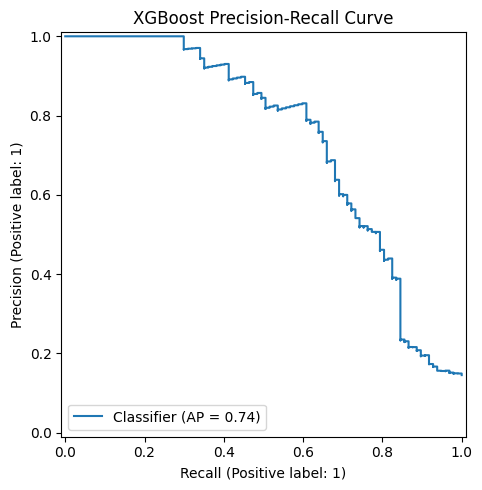

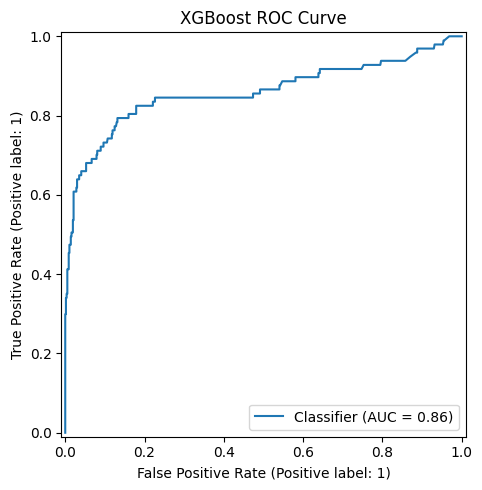

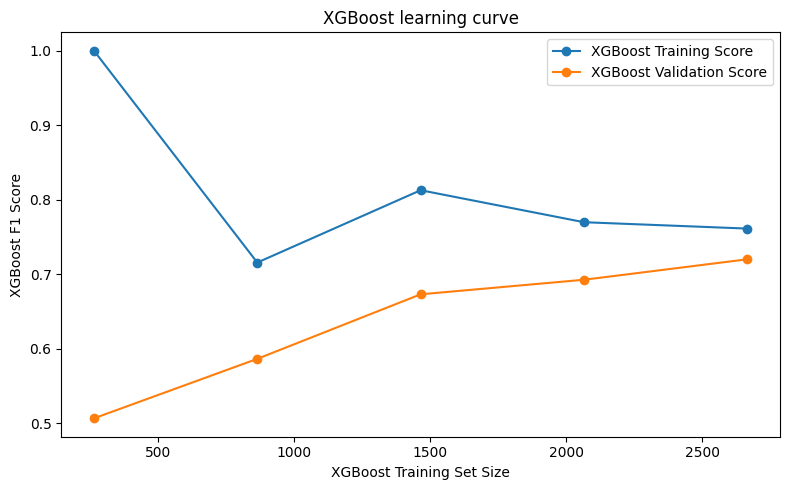

In [212]:
plot_evaluation(xgb_search, X_test, y_test, './models/xgboost/', 'XGBoost')

In [190]:
lr_report = return_report(logreg_search, X_test, y_test)
rf_report = return_report(rf_search, X_test, y_test)
xgboost_report = return_report(xgb_search, X_test, y_test)

In [196]:
report_df = pd.DataFrame([lr_report, rf_report, xgboost_report], columns=['accuracy', 'precision', 'recall', 'f1', 'roc'], index=['logistic regression', 'random forest', 'xgboost'])

In [197]:
report_df

,accuracy,precision,recall,f1,roc
logistic regression,0.859070,0.560000,0.144330,0.229508,0.813239
random forest,0.931034,0.849315,0.639175,0.729412,0.866359
xgboost,0.920540,0.823529,0.577320,0.678788,0.859242


In [202]:
report_df.to_excel('comparision.xlsx')